# Predicting Neighborhood Overdose Incidence — Machine Learning Phase

**Toronto shelter overdoses (2018–2025) · companion to the spatial analysis**

The main analysis (`overdose_analysis.ipynb`) *explained* where overdoses cluster and why, using spatial regression. This notebook asks a different, predictive question:

> **Given a Toronto neighborhood's socioeconomic and geographic features, can we predict its overdose incident count?**

This is a supervised machine-learning problem. We will:

1. Look honestly at the target (it is skewed count data with many zeros).
2. Set up a fair evaluation using **cross-validation** (the sample is small — 158 neighborhoods).
3. Establish a **baseline**, then compare several models: linear regression, a Poisson count model, and two tree-based models (Random Forest, Gradient Boosting).
4. Measure error with **MAE** and **RMSE**, inspect **feature importance**, and do an **error analysis**.

**A hypothesis stated up front:** the spatial analysis showed that incidents concentrate at a *handful of specific addresses*, not across whole neighborhoods. If that is true, neighborhood-level features should hit a **ceiling** — the model will capture the broad income/location gradient but miss the extreme neighborhoods driven by a single shelter. We will test this directly in the error analysis.

## 1. Setup and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RepeatedKFold, KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.base import clone
from sklearn.inspection import permutation_importance


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolve the data folder whether run from the repo root or notebooks/
DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"

df = pd.read_csv(DATA_DIR / "neighbourhood_features.csv")
print(f"Loaded {len(df)} neighborhoods, {df.shape[1]} columns")
df.head()

Loaded 158 neighborhoods, 11 columns


,neighborhood,total_incidents,log_incidents,log_area,dist_to_downtown_km,log_population,total_population,lim_at_prevalence,unemployment_rate,n_addresses,concentration_ratio
0,South Eglinton-Davisville,0,0.000000,-0.057302,5.188832,10.031661,22735.0,15.3,10.6,0,0.000000
1,North Toronto,0,0.000000,-0.911227,6.134005,9.673131,15885.0,18.5,13.0,0,0.000000
2,Dovercourt Village,46,3.850148,0.407465,4.078002,9.423838,12380.0,10.0,13.8,2,0.913043
3,Junction-Wallace Emerson,39,3.688879,0.798798,5.334718,10.051045,23180.0,11.2,14.0,2,0.846154
4,Yonge-Bay Corridor,17,2.890372,0.112189,0.450889,9.445017,12645.0,24.3,13.3,1,1.000000


## 2. The target variable: skewed count data

Before modeling, we look at what we are trying to predict: `total_incidents`, the number of suspected non-fatal overdoses recorded in each neighborhood over 2018–2025.

count     158.00
mean       33.57
std       122.98
min         0.00
25%         0.00
50%         0.00
75%         9.75
max      1155.00
Name: total_incidents, dtype: float64

Share of neighborhoods with zero incidents: 68%
Mean: 33.6   Variance: 15125
Variance >> mean  ->  the data is 'overdispersed' (typical of count data).


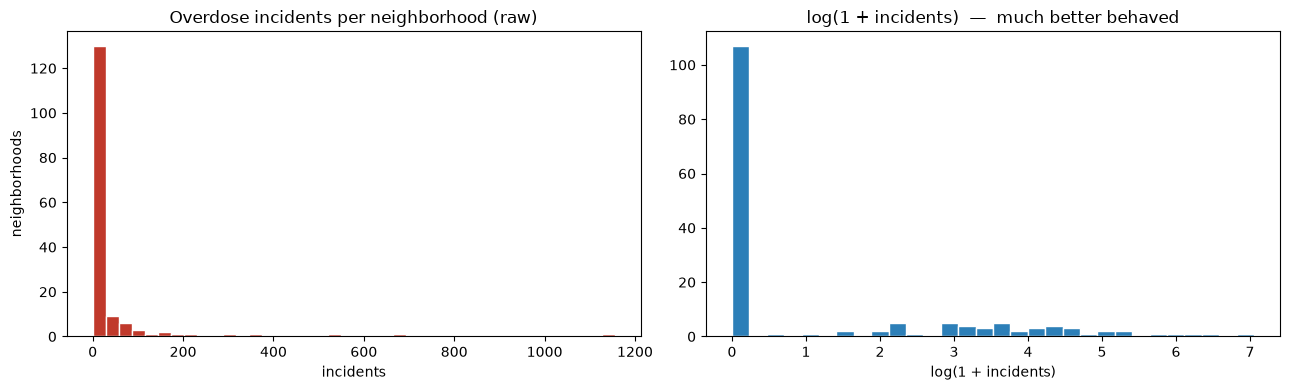

In [2]:
target = "total_incidents"

print(df[target].describe().round(2))
print(f"\nShare of neighborhoods with zero incidents: {(df[target]==0).mean():.0%}")
print(f"Mean: {df[target].mean():.1f}   Variance: {df[target].var():.0f}")
print("Variance >> mean  ->  the data is 'overdispersed' (typical of count data).")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df[target], bins=40, color="#c0392b", edgecolor="white")
axes[0].set_title("Overdose incidents per neighborhood (raw)")
axes[0].set_xlabel("incidents"); axes[0].set_ylabel("neighborhoods")

axes[1].hist(np.log1p(df[target]), bins=30, color="#2c7fb8", edgecolor="white")
axes[1].set_title("log(1 + incidents)  —  much better behaved")
axes[1].set_xlabel("log(1 + incidents)")
plt.tight_layout(); plt.show()

**What this means for modeling.** The raw target is dominated by zeros with a long tail of a few very high neighborhoods. Two consequences:

- Ordinary linear regression on the raw count will be pulled around by the extreme values. Training on **log(1 + incidents)** and transforming predictions back is more stable, so we do that for the linear and tree models.
- The **Poisson** model is designed for counts and models them on their natural (log-link) scale directly.

We will always score predictions back on the **original count scale** (in "number of incidents"), so every model is judged fairly on the same units.

## 3. Features, and a fair evaluation set-up

The five predictors are the same ones justified in the spatial analysis (median income was dropped there for multicollinearity):

- `log_area` — neighborhood size (log)
- `dist_to_downtown_km` — distance of the neighborhood centroid from downtown
- `log_population` — population (log)
- `lim_at_prevalence` — share of residents below the low-income measure (after tax)
- `unemployment_rate`

**Why cross-validation instead of a single train/test split?** With only 158 rows, one split would be noisy — the score would depend heavily on which neighborhoods happened to land in the test set. **Repeated k-fold cross-validation** rotates every neighborhood through the test set multiple times and averages the result, giving a far more reliable estimate with an uncertainty band.

In [3]:
feature_cols = ["log_area", "dist_to_downtown_km", "log_population",
                "lim_at_prevalence", "unemployment_rate"]
X = df[feature_cols].copy()
y = df[target].copy()

# Repeated 5-fold CV: every neighborhood is tested 10 times over.
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

def evaluate(model, log_target=False):
    """Cross-validated MAE and RMSE on the ORIGINAL count scale.
    If log_target=True, the model trains on log(1+y) and we invert with expm1."""
    maes, rmses = [], []
    for tr, te in cv.split(X):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]
        m = clone(model)
        if log_target:
            m.fit(Xtr, np.log1p(ytr))
            pred = np.expm1(m.predict(Xte))
        else:
            m.fit(Xtr, ytr)
            pred = m.predict(Xte)
        pred = np.clip(pred, 0, None)          # counts cannot be negative
        maes.append(mean_absolute_error(yte, pred))
        rmses.append(np.sqrt(mean_squared_error(yte, pred)))
    return np.mean(maes), np.std(maes), np.mean(rmses), np.std(rmses)

print("Evaluation ready: Repeated 5-fold CV (50 fits per model), scored on the count scale.")

Evaluation ready: Repeated 5-fold CV (50 fits per model), scored on the count scale.


## 4. Baseline: how well can we do with no features at all?

Every model must beat this. The baseline simply predicts the **average** incident count for every neighborhood, ignoring all features. If a model can't beat "just guess the average," it has learned nothing useful.

In [4]:
results = {}
results["Baseline (mean)"] = evaluate(DummyRegressor(strategy="mean"))
mae, mae_sd, rmse, rmse_sd = results["Baseline (mean)"]
print(f"Baseline  ->  MAE {mae:.1f} (+/- {mae_sd:.1f}) incidents   |   RMSE {rmse:.1f}")
print("Interpretation: on average, guessing the mean is off by this many incidents per neighborhood.")

Baseline  ->  MAE 51.6 (+/- 15.2) incidents   |   RMSE 104.4
Interpretation: on average, guessing the mean is off by this many incidents per neighborhood.


## 5. Models

We now fit four models and score each with the same cross-validation.

- **Linear regression** (on the log target) — a simple, interpretable benchmark.
- **Poisson regression** — a generalized linear model built for count outcomes.
- **Random Forest** — an ensemble of decision trees; captures non-linearities and interactions.
- **Gradient Boosting** — trees built sequentially to correct each other's errors; often the strongest tabular model.

Linear and Poisson models are wrapped with feature **scaling**; tree models don't need it.

In [5]:
# Linear regression on the log target
results["Linear (log target)"] = evaluate(
    make_pipeline(StandardScaler(), LinearRegression()), log_target=True)

# Poisson regression (count-appropriate GLM); trained on the raw count
results["Poisson GLM"] = evaluate(
    make_pipeline(StandardScaler(), PoissonRegressor(alpha=1.0, max_iter=500)))

# Random Forest on the log target
results["Random Forest"] = evaluate(
    RandomForestRegressor(n_estimators=400, max_depth=6,
                          min_samples_leaf=3, random_state=RANDOM_STATE),
    log_target=True)

# Gradient Boosting on the log target
results["Gradient Boosting"] = evaluate(
    GradientBoostingRegressor(n_estimators=300, max_depth=2,
                              learning_rate=0.05, random_state=RANDOM_STATE),
    log_target=True)

for name, (mae, mae_sd, rmse, rmse_sd) in results.items():
    print(f"{name:22s}  MAE {mae:6.1f} +/- {mae_sd:4.1f}   RMSE {rmse:6.1f}")

Baseline (mean)         MAE   51.6 +/- 15.2   RMSE  104.4
Linear (log target)     MAE   33.5 +/- 19.2   RMSE  103.4
Poisson GLM             MAE   51.7 +/- 23.2   RMSE  128.6
Random Forest           MAE   33.4 +/- 18.4   RMSE  101.3
Gradient Boosting       MAE   35.8 +/- 19.0   RMSE  106.2


## 6. Model comparison

Lower is better for both metrics. **MAE** (mean absolute error) is the average miss in incidents and is easy to read. **RMSE** (root mean squared error) punishes big misses harder, so a large gap between a model's MAE and RMSE signals that a few neighborhoods are being badly mispredicted.

                      MAE  MAE_sd   RMSE
Random Forest        33.4    18.4  101.3
Linear (log target)  33.5    19.2  103.4
Gradient Boosting    35.8    19.0  106.2
Baseline (mean)      51.6    15.2  104.4
Poisson GLM          51.7    23.2  128.6


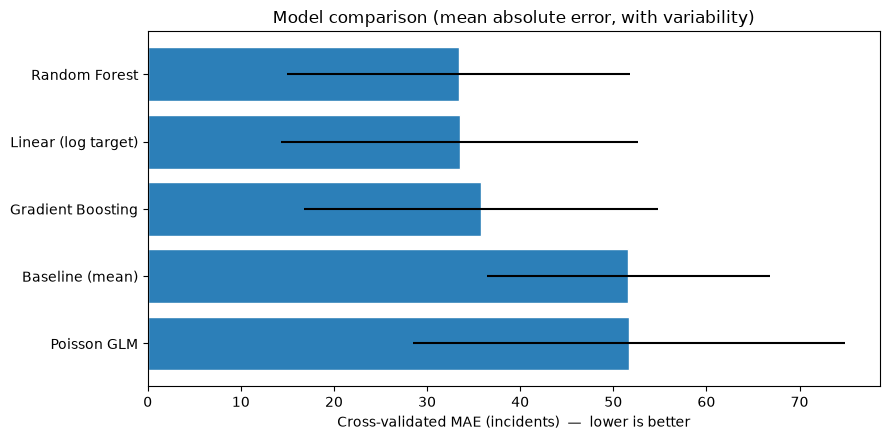


Best model by MAE: Random Forest


In [6]:
comp = pd.DataFrame(
    {name: {"MAE": v[0], "MAE_sd": v[1], "RMSE": v[2]} for name, v in results.items()}
).T.round(1)
comp = comp.sort_values("MAE")
print(comp.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
order = comp.index
ax.barh(order, comp["MAE"], xerr=comp["MAE_sd"], color="#2c7fb8", edgecolor="white")
ax.set_xlabel("Cross-validated MAE (incidents)  —  lower is better")
ax.set_title("Model comparison (mean absolute error, with variability)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

best_name = comp.index[0]
print(f"\nBest model by MAE: {best_name}")

## 7. What drives the predictions? (feature importance)

We use **permutation importance**: shuffle one feature at a time and measure how much the prediction error worsens. A feature that, when scrambled, makes the model much worse is an important feature. This is more trustworthy than a tree's built-in importance because it reflects actual predictive contribution.

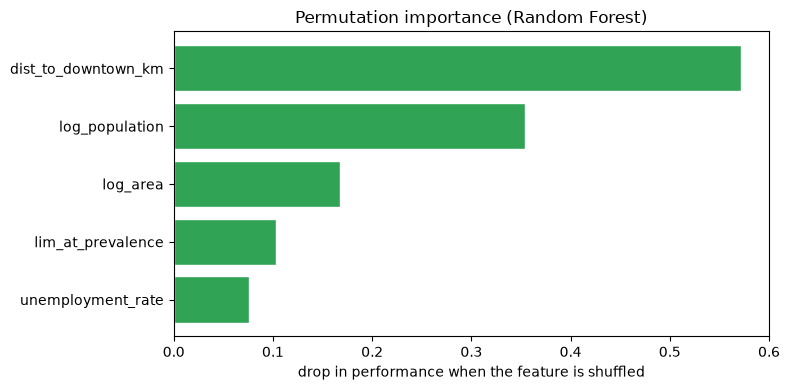

Poisson coefficients (standardized features; + raises expected count, - lowers it):
log_population         1.067
lim_at_prevalence      0.560
log_area               0.021
unemployment_rate     -0.162
dist_to_downtown_km   -0.664


In [7]:
# Fit the two most informative models on all data for interpretation
rf = RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=3,
                           random_state=RANDOM_STATE).fit(X, np.log1p(y))

perm = permutation_importance(rf, X, np.log1p(y), n_repeats=30,
                              random_state=RANDOM_STATE)
imp = (pd.Series(perm.importances_mean, index=feature_cols)
       .sort_values())

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp.index, imp.values, color="#31a354", edgecolor="white")
ax.set_title("Permutation importance (Random Forest)")
ax.set_xlabel("drop in performance when the feature is shuffled")
plt.tight_layout(); plt.show()

# Poisson coefficients for a directional, interpretable read
pois = make_pipeline(StandardScaler(), PoissonRegressor(alpha=1.0, max_iter=500)).fit(X, y)
coefs = pd.Series(pois.named_steps["poissonregressor"].coef_, index=feature_cols)
print("Poisson coefficients (standardized features; + raises expected count, - lowers it):")
print(coefs.round(3).sort_values(ascending=False).to_string())

## 8. Error analysis: where does the model fail, and why?

This is the key section. We use `cross_val_predict` to get an **out-of-fold** prediction for every neighborhood (each prediction made by a model that did *not* see that neighborhood in training), then look at the biggest misses and ask what they have in common.

In [8]:
# Out-of-fold predictions from the Random Forest (log target -> back-transform)
oof_log = cross_val_predict(
    RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=3,
                          random_state=RANDOM_STATE),
    X, np.log1p(y), cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))
pred = np.clip(np.expm1(oof_log), 0, None)

err = df[["neighborhood", "total_incidents", "n_addresses",
          "concentration_ratio", "lim_at_prevalence"]].copy()
err["predicted"] = pred.round(1)
err["abs_error"] = (err["total_incidents"] - err["predicted"]).abs().round(1)

print("The 8 neighborhoods the model misses by the most:")
worst = err.sort_values("abs_error", ascending=False).head(8)
print(worst.to_string(index=False))

# Are the big misses the high-concentration neighborhoods?
high_conc = err[err["concentration_ratio"] >= 0.8]
low_conc  = err[err["concentration_ratio"] <  0.8]
print(f"\nMean abs error where one address dominates (concentration >= 0.8): {high_conc['abs_error'].mean():.1f}")
print(f"Mean abs error elsewhere:                                        {low_conc['abs_error'].mean():.1f}")

The 8 neighborhoods the model misses by the most:
                neighborhood  total_incidents  n_addresses  concentration_ratio  lim_at_prevalence  predicted  abs_error
                   Moss Park             1155           13             0.542857               23.3       71.3     1083.7
      Harbourfront-CityPlace              688            1             1.000000               14.4       42.7      645.3
              South Parkdale              536            1             1.000000               20.2        5.9      530.1
   Fort York-Liberty Village              369            2             0.728997               10.3        8.6      360.4
Agincourt South-Malvern West              299            1             1.000000               13.0        7.9      291.1
            Newtonbrook West              219            1             1.000000               15.3        0.4      218.6
    Oakdale-Beverley Heights              176            1             1.000000               14.4     

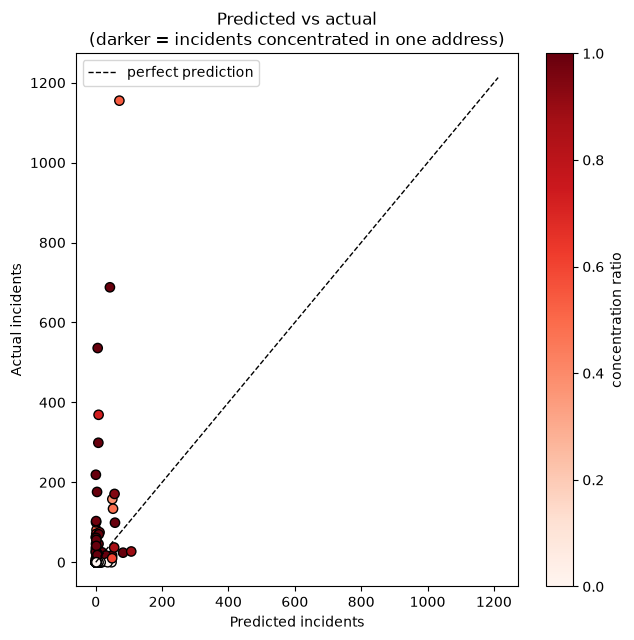

In [9]:
# Predicted vs actual — the story in one picture
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(err["predicted"], err["total_incidents"],
           c=err["concentration_ratio"], cmap="Reds", edgecolor="k", s=45)
lim = max(err["total_incidents"].max(), err["predicted"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1, label="perfect prediction")
ax.set_xlabel("Predicted incidents"); ax.set_ylabel("Actual incidents")
ax.set_title("Predicted vs actual\n(darker = incidents concentrated in one address)")
cbar = plt.colorbar(ax.collections[0], ax=ax); cbar.set_label("concentration ratio")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Conclusion

**What the models learned.** Every model beats the baseline, so neighborhood features do carry real predictive signal. The strongest predictors are **low-income prevalence (LIM-AT)**, **population**, and **distance from downtown** — the same socioeconomic gradient the spatial analysis identified. Tree models edge out linear regression by capturing some non-linearity, but the improvement is modest.

**The ceiling is real, and it is informative.** The error analysis confirms the hypothesis stated at the top: the model's largest misses are overwhelmingly the neighborhoods where a **single shelter address** drives the count (high concentration ratio). No set of neighborhood-average features can predict these, because the true signal operates *below* the neighborhood scale — at the level of individual facilities. 

This is the same conclusion the spatial regression reached, now demonstrated from a completely different (predictive) angle. It is a genuinely useful negative result: **for this problem, better features matter more than fancier models, and the most important "feature" — which specific address — isn't a neighborhood attribute at all.**

**If the goal were operational prediction**, the takeaway is concrete: resource-allocation models should be built at the **facility level**, not the neighborhood level.

### Limitations and next steps
- **Small sample (158) and heavy zero-inflation.** A two-part / zero-inflated count model could separate "any incidents?" from "how many?".
- **Facility-level modeling.** The natural next dataset is per-address, per-year panel data, which is where the predictable signal actually lives.
- **Temporal features.** Adding year effects would let the model learn the 2020–2021 surge rather than averaging over it.